In [4]:
#PACKEGE IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

%pip install geopandas

from PIL import Image
from IPython.display import display

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
#CSV ASSIGNMENTS

ark_nri = pd.read_csv("Arkansas_NRI_filtered.csv", low_memory = True)
de_nri = pd.read_csv("Delaware_NRI_filtered.csv", low_memory = True)

ark_svi = pd.read_csv("Arkansas.csv", low_memory = True)
de_svi = pd.read_csv("Delaware.csv", low_memory = True)

nri_dictionary = pd.read_csv("NRIDataDictionary.csv", low_memory = True)
nri_hazard_info = pd.read_csv("NRI_HazardInfo.csv", low_memory = True)

ark_nri = pd.DataFrame(ark_nri)
de_nri = pd.DataFrame(de_nri)
ark_svi = pd.DataFrame(ark_svi)
de_svi = pd.DataFrame(de_svi)
nri_dictionary = pd.DataFrame(nri_dictionary)
nri_hazard_info = pd.DataFrame(nri_hazard_info)

print("Arkansas NRI shape:", ark_nri.shape)
print("Delaware NRI shape:", de_nri.shape)
print("Arkansas SVI shape:", ark_svi.shape)
print("Delaware SVI shape:", de_svi.shape)
print("NRI dictionary shape:", nri_dictionary.shape)
print("Hazard info shape:", nri_hazard_info.shape)

Arkansas NRI shape: (823, 10)
Delaware NRI shape: (259, 10)
Arkansas SVI shape: (823, 158)
Delaware SVI shape: (259, 158)
NRI dictionary shape: (479, 9)
Hazard info shape: (18, 13)


In [4]:
#COLUMN CHECKS

print("Arkansas NRI columns:")
print(ark_nri.columns.tolist())

print("\nDelaware NRI columns:")
print(de_nri.columns.tolist())

print("\nArkansas SVI columns:")
print(ark_svi.columns.tolist())

print("\nDelaware SVI columns:")
print(de_svi.columns.tolist())

Arkansas NRI columns:
['STATE', 'COUNTY', 'TRACTFIPS', 'STCOFIPS', 'RISK_SCORE', 'RISK_VALUE', 'HAIL_AFREQ', 'HAIL_EXPA', 'HWAV_AFREQ', 'HWAV_EXPA']

Delaware NRI columns:
['STATE', 'COUNTY', 'TRACTFIPS', 'STCOFIPS', 'RISK_SCORE', 'RISK_VALUE', 'HAIL_AFREQ', 'HAIL_EXPA', 'HWAV_AFREQ', 'HWAV_EXPA']

Arkansas SVI columns:
['ST', 'STATE', 'ST_ABBR', 'STCNTY', 'COUNTY', 'FIPS', 'LOCATION', 'AREA_SQMI', 'E_TOTPOP', 'M_TOTPOP', 'E_HU', 'M_HU', 'E_HH', 'M_HH', 'E_POV150', 'M_POV150', 'E_UNEMP', 'M_UNEMP', 'E_HBURD', 'M_HBURD', 'E_NOHSDP', 'M_NOHSDP', 'E_UNINSUR', 'M_UNINSUR', 'E_AGE65', 'M_AGE65', 'E_AGE17', 'M_AGE17', 'E_DISABL', 'M_DISABL', 'E_SNGPNT', 'M_SNGPNT', 'E_LIMENG', 'M_LIMENG', 'E_MINRTY', 'M_MINRTY', 'E_MUNIT', 'M_MUNIT', 'E_MOBILE', 'M_MOBILE', 'E_CROWD', 'M_CROWD', 'E_NOVEH', 'M_NOVEH', 'E_GROUPQ', 'M_GROUPQ', 'EP_POV150', 'MP_POV150', 'EP_UNEMP', 'MP_UNEMP', 'EP_HBURD', 'MP_HBURD', 'EP_NOHSDP', 'MP_NOHSDP', 'EP_UNINSUR', 'MP_UNINSUR', 'EP_AGE65', 'MP_AGE65', 'EP_AGE17', 'MP_AG

In [6]:
ark_nri['STCNTY'] = ark_nri['STCOFIPS']
de_nri['STCNTY'] = de_nri['STCOFIPS']

## Make sure the states are correct
ark_nri = ark_nri[ark_nri["STATE"] == "Arkansas"].copy()
de_nri = de_nri[de_nri["STATE"] == "Delaware"].copy()

ark_svi = ark_svi[ark_svi["STATE"] == "Arkansas"].copy()
de_svi = de_svi[de_svi["STATE"] == "Delaware"].copy()

print("Arkansas NRI cleaned shape:", ark_nri.shape)
print("Delaware NRI cleaned shape:", de_nri.shape)
print("Arkansas SVI cleaned shape:", ark_svi.shape)
print("Delaware SVI cleaned shape:", de_svi.shape)

Arkansas NRI cleaned shape: (823, 11)
Delaware NRI cleaned shape: (259, 11)
Arkansas SVI cleaned shape: (823, 158)
Delaware SVI cleaned shape: (259, 158)


In [7]:
print(nri_dictionary.head())
print(nri_hazard_info.head())

   Sort    Field Name   Field Alias      Type  Length Relevant Layer  \
0     1      OBJECTID      OBJECTID   Integer     4.0            NaN   
1     2         Shape         Shape  Geometry     NaN            NaN   
2     3  Shape_Length  Shape_Length    Double     8.0            NaN   
3     4    Shape_Area    Shape_Area    Double     8.0            NaN   
4     5         STATE    State Name    String   250.0            All   

  Metric Type Version   Version Date  
0         NaN  1.20.0  December 2025  
1         NaN  1.20.0  December 2025  
2         NaN  1.20.0  December 2025  
3         NaN  1.20.0  December 2025  
4         NaN  1.20.0  December 2025  
   OID_            Hazard Prefix          Service Start   End TotalYears  \
0     1         Avalanche   AVLN        Avalanche  1994  2023         30   
1     2  Coastal Flooding   CFLD  CoastalFlooding  2025  2025          1   
2     3         Cold Wave   CWAV         ColdWave  2005  2024         19   
3     4           Drought   D

Tests and Checks

In [9]:
## Example variable lookups
fields_to_check = [
    "RISK_SCORE",
    "RISK_VALUE",
    "HAIL_AFREQ",
    "HAIL_EXPA",
    "HWAV_AFREQ",
    "HWAV_EXPA"
]

dictionary_subset = nri_dictionary[nri_dictionary["Field Name"].isin(fields_to_check)]
print(dictionary_subset[["Field Name", "Field Alias", "Type", "Metric Type"]])

     Field Name                               Field Alias    Type  \
18   RISK_VALUE   National Risk Index - Value - Composite  Double   
19   RISK_SCORE   National Risk Index - Score - Composite  Double   
152  HAIL_AFREQ               Hail - Annualized Frequency  Double   
156   HAIL_EXPA       Hail - Exposure - Agriculture Value  Double   
178  HWAV_AFREQ          Heat Wave - Annualized Frequency  Double   
182   HWAV_EXPA  Heat Wave - Exposure - Agriculture Value  Double   

                      Metric Type  
18                          Value  
19                          Score  
152          Annualized Frequency  
156  Exposure - Agriculture Value  
178          Annualized Frequency  
182  Exposure - Agriculture Value  


In [10]:
## Check hazard definitions for HAIL and HWAV
hazard_subset = nri_hazard_info[nri_hazard_info["Prefix"].isin(["HAIL", "HWAV"])]
print(hazard_subset[["Hazard", "Prefix", "FrequencyModel", "PeriodOfRecord"]])

      Hazard Prefix        FrequencyModel        PeriodOfRecord
5       Hail   HAIL  Annualized Frequency  1986-2023 (38 years)
6  Heat Wave   HWAV  Annualized Frequency  2005-2024 (19 years)


In [11]:
print(ark_svi[["STATE", "COUNTY", "STCNTY", "FIPS", "RPL_THEMES"]].head())
print(de_svi[["STATE", "COUNTY", "STCNTY", "FIPS", "RPL_THEMES"]].head())

      STATE           COUNTY  STCNTY        FIPS  RPL_THEMES
0  Arkansas  Arkansas County    5001  5001480100      0.2439
1  Arkansas  Arkansas County    5001  5001480200      0.0512
2  Arkansas  Arkansas County    5001  5001480300      0.4707
3  Arkansas  Arkansas County    5001  5001480400      0.9561
4  Arkansas  Arkansas County    5001  5001480500      0.4500
      STATE       COUNTY  STCNTY         FIPS  RPL_THEMES
0  Delaware  Kent County   10001  10001040100      0.4824
1  Delaware  Kent County   10001  10001040201      0.5176
2  Delaware  Kent County   10001  10001040203      0.7686
3  Delaware  Kent County   10001  10001040204      0.5373
4  Delaware  Kent County   10001  10001040205      0.7725


In [14]:
complete_ark = pd.merge(ark_nri, ark_svi, on = 'STCNTY', suffixes = ("_NRI", "_SVI"))
complete_de = pd.merge(de_nri, de_svi, on = 'STCNTY', suffixes = ("_NRI", "_SVI"))

print("Arkansas merged shape:", complete_ark.shape)
print("Delaware merged shape:", complete_de.shape)

print(complete_ark.columns.tolist())

Arkansas merged shape: (26309, 168)
Delaware merged shape: (27893, 168)
['STATE_NRI', 'COUNTY_NRI', 'TRACTFIPS', 'STCOFIPS', 'RISK_SCORE', 'RISK_VALUE', 'HAIL_AFREQ', 'HAIL_EXPA', 'HWAV_AFREQ', 'HWAV_EXPA', 'STCNTY', 'ST', 'STATE_SVI', 'ST_ABBR', 'COUNTY_SVI', 'FIPS', 'LOCATION', 'AREA_SQMI', 'E_TOTPOP', 'M_TOTPOP', 'E_HU', 'M_HU', 'E_HH', 'M_HH', 'E_POV150', 'M_POV150', 'E_UNEMP', 'M_UNEMP', 'E_HBURD', 'M_HBURD', 'E_NOHSDP', 'M_NOHSDP', 'E_UNINSUR', 'M_UNINSUR', 'E_AGE65', 'M_AGE65', 'E_AGE17', 'M_AGE17', 'E_DISABL', 'M_DISABL', 'E_SNGPNT', 'M_SNGPNT', 'E_LIMENG', 'M_LIMENG', 'E_MINRTY', 'M_MINRTY', 'E_MUNIT', 'M_MUNIT', 'E_MOBILE', 'M_MOBILE', 'E_CROWD', 'M_CROWD', 'E_NOVEH', 'M_NOVEH', 'E_GROUPQ', 'M_GROUPQ', 'EP_POV150', 'MP_POV150', 'EP_UNEMP', 'MP_UNEMP', 'EP_HBURD', 'MP_HBURD', 'EP_NOHSDP', 'MP_NOHSDP', 'EP_UNINSUR', 'MP_UNINSUR', 'EP_AGE65', 'MP_AGE65', 'EP_AGE17', 'MP_AGE17', 'EP_DISABL', 'MP_DISABL', 'EP_SNGPNT', 'MP_SNGPNT', 'EP_LIMENG', 'MP_LIMENG', 'EP_MINRTY', 'MP_MINRTY'

In [15]:
print("Arkansas NRI missing values:")
print(ark_nri.isna().sum())

print("\nDelaware NRI missing values:")
print(de_nri.isna().sum())

print("\nArkansas SVI missing values:")
print(ark_svi.isna().sum())

print("\nDelaware SVI missing values:")
print(de_svi.isna().sum())

Arkansas NRI missing values:
STATE         0
COUNTY        0
TRACTFIPS     0
STCOFIPS      0
RISK_SCORE    0
RISK_VALUE    0
HAIL_AFREQ    0
HAIL_EXPA     0
HWAV_AFREQ    0
HWAV_EXPA     0
STCNTY        0
dtype: int64

Delaware NRI missing values:
STATE         0
COUNTY        0
TRACTFIPS     0
STCOFIPS      0
RISK_SCORE    0
RISK_VALUE    0
HAIL_AFREQ    0
HAIL_EXPA     0
HWAV_AFREQ    0
HWAV_EXPA     0
STCNTY        0
dtype: int64

Arkansas SVI missing values:
ST              0
STATE           0
ST_ABBR         0
STCNTY          0
COUNTY          0
               ..
MP_NHPI         0
EP_TWOMORE      0
MP_TWOMORE      0
EP_OTHERRACE    0
MP_OTHERRACE    0
Length: 158, dtype: int64

Delaware SVI missing values:
ST              0
STATE           0
ST_ABBR         0
STCNTY          0
COUNTY          0
               ..
MP_NHPI         0
EP_TWOMORE      0
MP_TWOMORE      0
EP_OTHERRACE    0
MP_OTHERRACE    0
Length: 158, dtype: int64


In [17]:

ark_missing_summary = pd.DataFrame({
    "Missing_Count": complete_ark.isna().sum(),
    "Missing_Percent": (complete_ark.isna().sum() / len(complete_ark)) * 100
}).sort_values("Missing_Percent", ascending = False)

de_missing_summary = pd.DataFrame({
    "Missing_Count": complete_de.isna().sum(),
    "Missing_Percent": (complete_de.isna().sum() / len(complete_de)) * 100
}).sort_values("Missing_Percent", ascending = False)

print("Arkansas missing summary:")
print(ark_missing_summary.head(20))

print("\nDelaware missing summary:")
print(de_missing_summary.head(20))

Arkansas missing summary:
            Missing_Count  Missing_Percent
STATE_NRI               0              0.0
COUNTY_NRI              0              0.0
TRACTFIPS               0              0.0
STCOFIPS                0              0.0
RISK_SCORE              0              0.0
RISK_VALUE              0              0.0
HAIL_AFREQ              0              0.0
HAIL_EXPA               0              0.0
HWAV_AFREQ              0              0.0
HWAV_EXPA               0              0.0
STCNTY                  0              0.0
ST                      0              0.0
STATE_SVI               0              0.0
ST_ABBR                 0              0.0
COUNTY_SVI              0              0.0
FIPS                    0              0.0
LOCATION                0              0.0
AREA_SQMI               0              0.0
E_TOTPOP                0              0.0
M_TOTPOP                0              0.0

Delaware missing summary:
            Missing_Count  Missing_Percent
S

In [18]:
## Fill numeric columns with the median
complete_ark_clean = complete_ark.copy()
complete_de_clean = complete_de.copy()

ark_num_cols = complete_ark_clean.select_dtypes(include = [np.number]).columns
de_num_cols = complete_de_clean.select_dtypes(include = [np.number]).columns

complete_ark_clean[ark_num_cols] = complete_ark_clean[ark_num_cols].fillna(
    complete_ark_clean[ark_num_cols].median()
)

complete_de_clean[de_num_cols] = complete_de_clean[de_num_cols].fillna(
    complete_de_clean[de_num_cols].median()
)

## Fill object columns with "Unknown"
ark_obj_cols = complete_ark_clean.select_dtypes(include = ["object"]).columns
de_obj_cols = complete_de_clean.select_dtypes(include = ["object"]).columns

complete_ark_clean[ark_obj_cols] = complete_ark_clean[ark_obj_cols].fillna("Unknown")
complete_de_clean[de_obj_cols] = complete_de_clean[de_obj_cols].fillna("Unknown")

print("Remaining missing values in Arkansas:", complete_ark_clean.isna().sum().sum())
print("Remaining missing values in Delaware:", complete_de_clean.isna().sum().sum())

Remaining missing values in Arkansas: 0
Remaining missing values in Delaware: 0


In [19]:
## Use hail frequency * hail exposure + heat wave frequency * heat wave exposure
## then combine with SVI percentile ranking

def normalize_column(series):
    if series.max() == series.min():
        return pd.Series(np.zeros(len(series)), index = series.index)
    return (series - series.min()) / (series.max() - series.min())

In [20]:
## Arkansas custom risk variables
complete_ark_clean['Hail_custom_risk'] = complete_ark_clean['HAIL_AFREQ'] * complete_ark_clean['HAIL_EXPA']
complete_ark_clean['Heat_custom_risk'] = complete_ark_clean['HWAV_AFREQ'] * complete_ark_clean['HWAV_EXPA']

complete_ark_clean['Hail_custom_risk_norm'] = normalize_column(complete_ark_clean['Hail_custom_risk'])
complete_ark_clean['Heat_custom_risk_norm'] = normalize_column(complete_ark_clean['Heat_custom_risk'])
complete_ark_clean['SVI_norm'] = normalize_column(complete_ark_clean['RPL_THEMES'])

complete_ark_clean['Proposed_Risk'] = (
    0.4 * complete_ark_clean['Hail_custom_risk_norm'] +
    0.4 * complete_ark_clean['Heat_custom_risk_norm'] +
    0.2 * complete_ark_clean['SVI_norm']
)

C:\Users\atmei\AppData\Local\Temp\ipykernel_12020\356962457.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  complete_ark_clean['Hail_custom_risk'] = complete_ark_clean['HAIL_AFREQ'] * complete_ark_clean['HAIL_EXPA']
C:\Users\atmei\AppData\Local\Temp\ipykernel_12020\356962457.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  complete_ark_clean['Heat_custom_risk'] = complete_ark_clean['HWAV_AFREQ'] * complete_ark_clean['HWAV_EXPA']
C:\Users\atmei\AppData\Local\Temp\ipykernel_12020\356962457.py:5: PerformanceWarning: DataFram

In [21]:
## Delaware custom risk variables
complete_de_clean['Hail_custom_risk'] = complete_de_clean['HAIL_AFREQ'] * complete_de_clean['HAIL_EXPA']
complete_de_clean['Heat_custom_risk'] = complete_de_clean['HWAV_AFREQ'] * complete_de_clean['HWAV_EXPA']

complete_de_clean['Hail_custom_risk_norm'] = normalize_column(complete_de_clean['Hail_custom_risk'])
complete_de_clean['Heat_custom_risk_norm'] = normalize_column(complete_de_clean['Heat_custom_risk'])
complete_de_clean['SVI_norm'] = normalize_column(complete_de_clean['RPL_THEMES'])

complete_de_clean['Proposed_Risk'] = (
    0.4 * complete_de_clean['Hail_custom_risk_norm'] +
    0.4 * complete_de_clean['Heat_custom_risk_norm'] +
    0.2 * complete_de_clean['SVI_norm']
)

C:\Users\atmei\AppData\Local\Temp\ipykernel_12020\3098724985.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  complete_de_clean['Hail_custom_risk'] = complete_de_clean['HAIL_AFREQ'] * complete_de_clean['HAIL_EXPA']
C:\Users\atmei\AppData\Local\Temp\ipykernel_12020\3098724985.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  complete_de_clean['Heat_custom_risk'] = complete_de_clean['HWAV_AFREQ'] * complete_de_clean['HWAV_EXPA']
C:\Users\atmei\AppData\Local\Temp\ipykernel_12020\3098724985.py:5: PerformanceWarning: DataFrame i

In [22]:
# SUmmary table 1

ark_summary = complete_ark_clean.groupby("COUNTY_SVI").agg(
    Avg_NRI_Risk_Score = ("RISK_SCORE", "mean"),
    Avg_Proposed_Risk = ("Proposed_Risk", "mean"),
    Avg_SVI = ("RPL_THEMES", "mean")
).reset_index()

print(ark_summary)

           COUNTY_SVI  Avg_NRI_Risk_Score  Avg_Proposed_Risk   Avg_SVI
0     Arkansas County           76.152444           0.314846  0.431862
1       Ashley County           68.944247           0.241087  0.621271
2       Baxter County           76.308016           0.210058  0.457550
3       Benton County           52.486022           0.242809  0.332900
4        Boone County           87.315744           0.276713  0.333643
..                ...                 ...                ...       ...
70   Van Buren County           73.924504           0.209821  0.581717
71  Washington County           71.792737           0.237322  0.458535
72       White County           82.827346           0.228304  0.559058
73    Woodruff County           96.952778           0.446105  0.718300
74        Yell County           81.771570           0.404159  0.694500

[75 rows x 4 columns]


In [23]:
#Summary table 2

de_summary = complete_de_clean.groupby("COUNTY_SVI").agg(
    Avg_NRI_Risk_Score = ("RISK_SCORE", "mean"),
    Avg_Proposed_Risk = ("Proposed_Risk", "mean"),
    Avg_SVI = ("RPL_THEMES", "mean")
).reset_index()

print(de_summary)

          COUNTY_SVI  Avg_NRI_Risk_Score  Avg_Proposed_Risk    Avg_SVI
0        Kent County           45.659843           0.270375 -23.740034
1  New Castle County           41.846833           0.204432  -6.452749
2      Sussex County           60.197221           0.281835 -13.060308


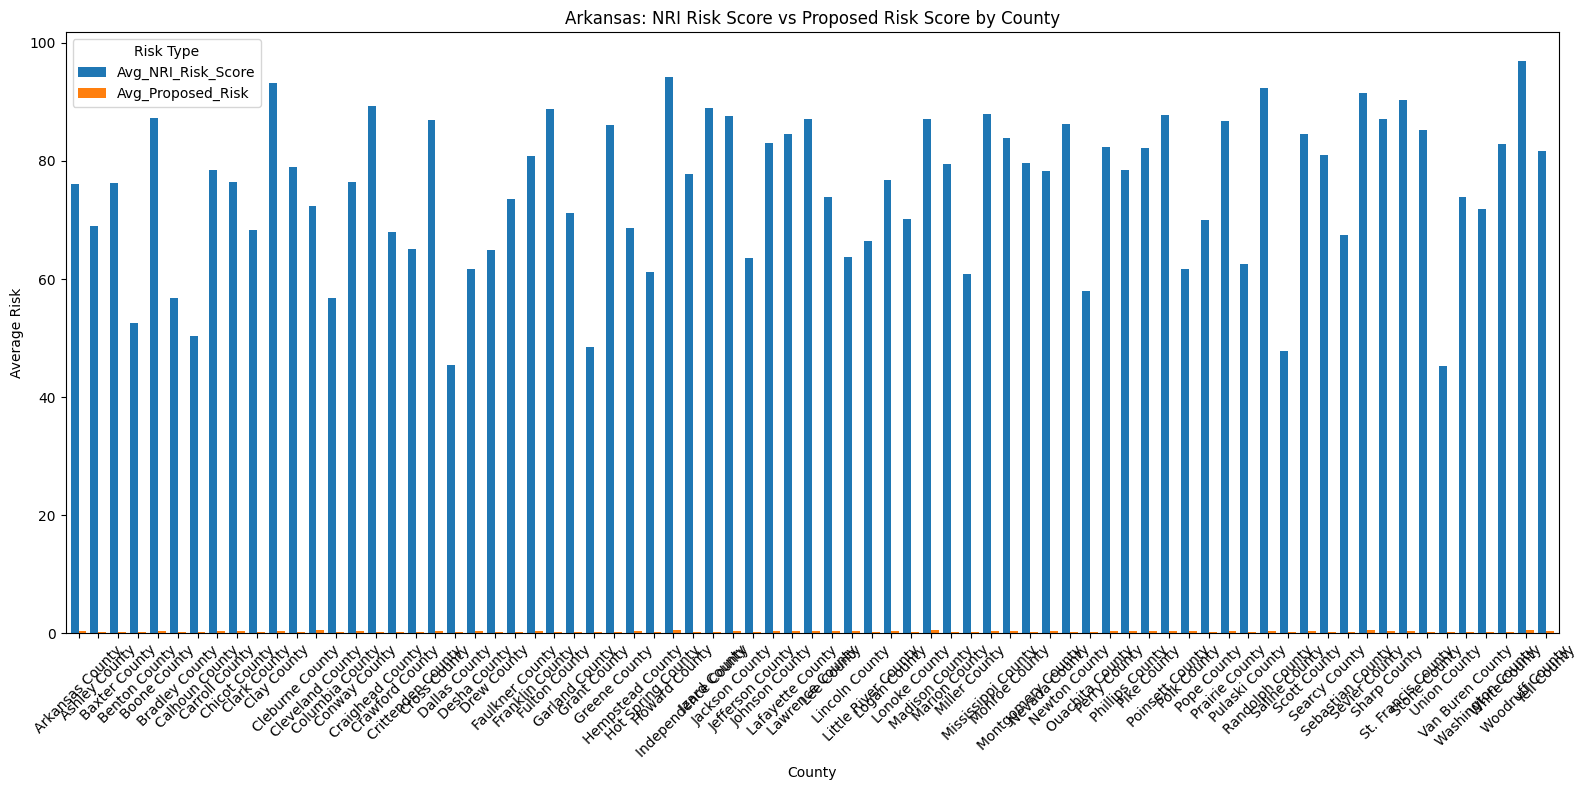

In [25]:
#Figure 1


ark_plot = ark_summary.set_index("COUNTY_SVI")

ark_plot[["Avg_NRI_Risk_Score", "Avg_Proposed_Risk"]].plot(
    kind = "bar",
    figsize = (16, 8),
    width = 0.8
)

plt.xlabel("County")
plt.ylabel("Average Risk")
plt.title("Arkansas: NRI Risk Score vs Proposed Risk Score by County")
plt.xticks(rotation = 45)
plt.legend(title = "Risk Type")
plt.tight_layout()
plt.show()

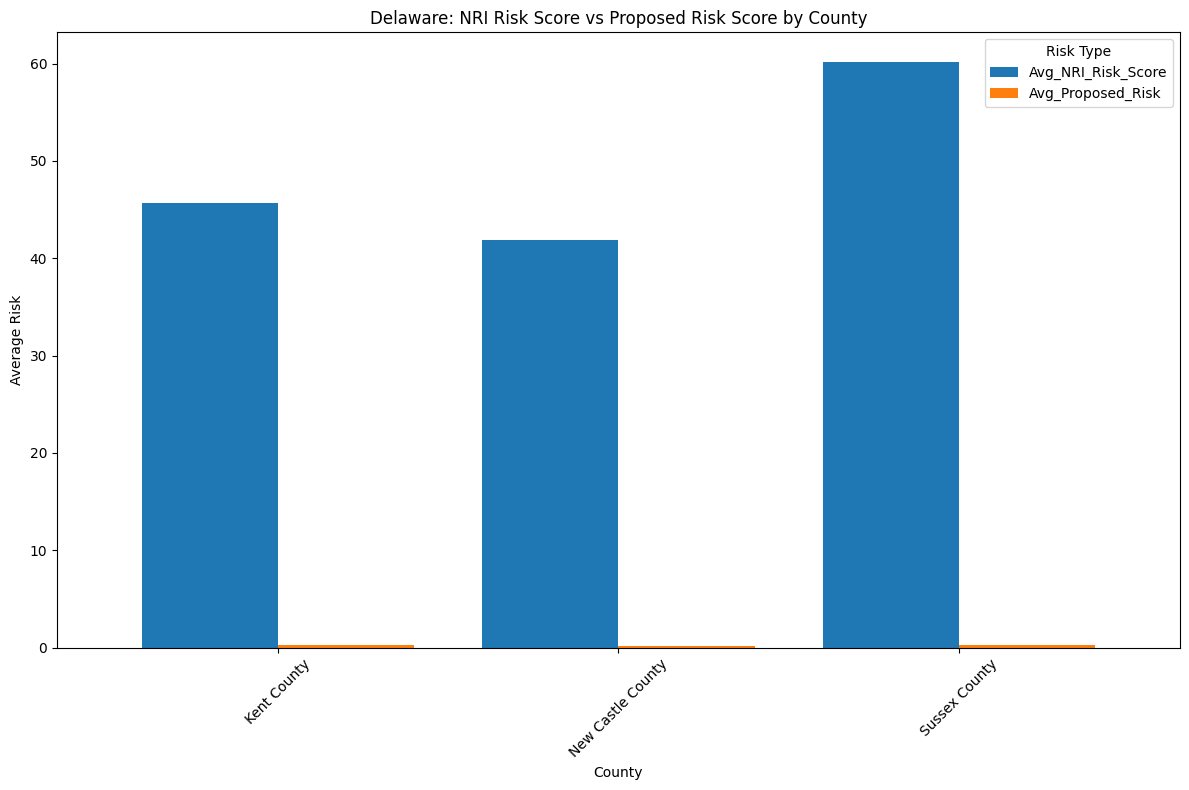

In [26]:
#Figure 2

de_plot = de_summary.set_index("COUNTY_SVI")

de_plot[["Avg_NRI_Risk_Score", "Avg_Proposed_Risk"]].plot(
    kind = "bar",
    figsize = (12, 8),
    width = 0.8
)

plt.xlabel("County")
plt.ylabel("Average Risk")
plt.title("Delaware: NRI Risk Score vs Proposed Risk Score by County")
plt.xticks(rotation = 45)
plt.legend(title = "Risk Type")
plt.tight_layout()
plt.show()

In [6]:
## Read the Census Tracts data
tracts = gpd.read_file("NRI_Shapefile_CensusTracts.shp")
##Verifications for Shape files
tracts.head()

,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,TRACTFIPS,...,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_N,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER,Shape_Leng,Shape_Area,geometry
0,T01001020100,Alabama,AL,01,Autauga,County,001,01001,020100,01001020100,...,7.410082e-09,0.000009,32.947366,214.404773,25.882367,Relatively Low,March 2023,19225.811017,1.388551e+07,"POLYGON ((-9626784.493 3827718.774, -9626802.4..."
1,T01001020200,Alabama,AL,01,Autauga,County,001,01001,020200,01001020200,...,7.410082e-09,0.000009,33.845738,335.526352,29.020596,Relatively Low,March 2023,11645.802680,4.687259e+06,"POLYGON ((-9625497.973 3827700.43, -9625504.76..."
2,T01001020300,Alabama,AL,01,Autauga,County,001,01001,020300,01001020300,...,7.410082e-09,0.000009,33.386570,494.226826,32.839033,Relatively Low,March 2023,12474.652420,7.550456e+06,"POLYGON ((-9623646.617 3823891.992, -9623666.3..."
3,T01001020400,Alabama,AL,01,Autauga,County,001,01001,020400,01001020400,...,7.410082e-09,0.000009,32.654955,517.167844,33.357513,Relatively Low,March 2023,14839.600848,9.007297e+06,"POLYGON ((-9622012.001 3826514.039, -9622007.2..."
4,T01001020501,Alabama,AL,01,Autauga,County,001,01001,020501,01001020501,...,7.410082e-09,0.000009,32.793527,558.901021,34.226799,Relatively Low,March 2023,13543.791893,8.736313e+06,"POLYGON ((-9619304.709 3823820.353, -9619304.3..."


In [7]:
###This checks for Coordinate Reference System (CRS)
#tracts.crs()
###Checks the geometries in the data
tracts.geometry.head()

0    POLYGON ((-9626784.493 3827718.774, -9626802.4...
1    POLYGON ((-9625497.973 3827700.43, -9625504.76...
2    POLYGON ((-9623646.617 3823891.992, -9623666.3...
3    POLYGON ((-9622012.001 3826514.039, -9622007.2...
4    POLYGON ((-9619304.709 3823820.353, -9619304.3...
Name: geometry, dtype: geometry

In [8]:
### Cleaning data - Dr. Lane's Example
# Check the projection and set it
tracts_clean = tracts.set_crs(epsg=4326,inplace=True, allow_override=True)
# 3. Now you can transform to a new CRS (e.g., Pseudo-Mercator)
tracts_clean = tracts_clean.to_crs(epsg=4326)
# Replace -9999 nulls with NaN
tracts_clean=tracts_clean.replace(-9999,np.nan)

In [9]:
# 1. Tell GeoPandas the data is actually Web Mercator (meters)
tracts_clean.crs="EPSG:3857"
# 2. Now properly convert it to degrees to match your xlim/ylim
tracts_clean = tracts_clean.to_crs(epsg=4326)
# Standard projection for US National maps
tracts_clean=tracts_clean.to_crs("ESRI:102003")

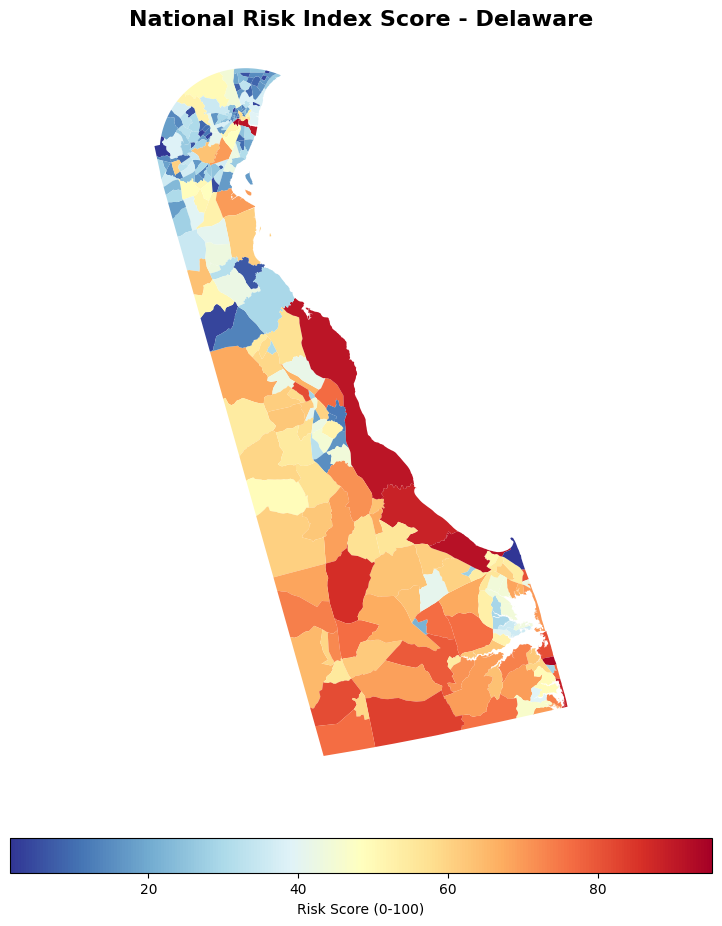

In [10]:







state_name = "Delaware"  # <-- Change this to any state

state_map = tracts_clean[tracts_clean["STATE"].str.lower() == state_name.lower()]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
state_map.plot(
    column="RISK_SCORE",
    cmap="RdYlBu_r",
    aspect = 1,
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds={"color": "lightgrey", "label": "No Data"},
)
ax.set_title(f"National Risk Index Score - {state_name}", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()